In [4]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as n
import glob
import xarray as xr
import seaborn as sns
import matplotlib.lines as mlines
import pandas as pd
import function_sampling_Thermal_forcing_files as fn
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.stats import linregress
from collections import Counter
sns.set_context("paper")
sns.set_style("whitegrid")
computed_name = 'ComputedScalarsHelene'
mnt_pth = '/Volumes/CrucialX8/computing/data/antarctica/' #mount path
pth_imip6hack= mnt_pth + 'ismip6_hackathon/ComputedScalars/' #write folder
pth_ismip6 =mnt_pth + 'ismip6_hackathon/' #read folder
pth_helene =mnt_pth + 'ismip6_hackathon/ComputedScalarsHelene/'

#*************************** choose variable,factor and path

variable2 = 'shelfmelt'
y2sec=-365.25*24*3600
factor = y2sec/10**3
pth = pth_helene

variable = 'iareafl'




variable3 = 'thermalforcing'
pth3 = pth_imip6hack
# variable2 = 'iareafl'
# factor = 1
# pth = pth_helene

# variable2 = 'iareagr'
# factor = 1
# pth = pth_helene


# variable2 = 'dslc_anom'
# factor = -1
# pth = pth_imip6hack

fpath = f'./figs/recalc_{variable2}_lin_ms/'
fname = f'average_{variable2}_'

In [15]:

 
expnames = ['expAE04']
removeFileID = [] # specify models to remove
 
metadata_file = 'Metadata.txt'
def get_model(string,exp):
    return string.split('/')[-1].split('AIS_')[-1].split('_'+str(exp))[0]

# Generate loop_info DataFrame
models=[]
paths =[]
exps =[]
for exp in expnames:
    lst = glob.glob(pth_helene+f'{exp}/shelfmelt/*.nc')
    lst.sort()

    for name in lst:
        model = get_model(name,exp)
        if model in removeFileID:
            continue
        else:
            models.append(model)
            paths.append(name)
            exps.append(exp)
df = pd.DataFrame({ 'Experiment': exps,'Model': models, 'Path': paths}) 
for i in range(1,19):
    df['sector_'+str(i)]=0
df['AIS']=0
df_org = df.copy()
metadata_file = 'Metadata_icefront.txt'
df_info = pd.read_csv(metadata_file)                 
df_info_model = df_info[df_info['fileID']==df.iloc[i].Model ]
df_info_model_exp = df_info_model[df_info_model['Experiment']==exp]
df_ms2k = pd.read_csv('./tables/linear_meltsensetivity_from_BMB_max_TFuntil2K.csv')
df_ms_n2k = pd.read_csv('./tables/linear_meltsensetivity_from_BMB_max_intercept_TFuntil2K.csv')

df_ms = pd.read_csv('./tables/linear_meltsensetivity_from_BMB_max.csv')
df_ms_n = pd.read_csv('./tables/linear_meltsensetivity_from_BMB_max_intercept.csv')

df_ms2100 = pd.read_csv('./tables/linear_meltsensetivity_from_BMB_max_time2100.csv')
df_ms_n2100 = pd.read_csv('./tables/linear_meltsensetivity_from_BMB_max_intercept_time2100.csv')

In [28]:
pds_m = [df_ms,df_ms2k,df_ms2100]
pds_n = [df_ms_n,df_ms_n2k,df_ms_n2100]
methods = ['$BMB_{max}$','$BMB_{max2K}$','$BMB_{max2100}$']

In [17]:
dic_area_of_interest ={}

dic_area_of_interest['Aurora'] = ['_sector_4']

renamer = {}
renamer['DOE_MALI_4km']='DOE_MALI_1'
renamer['DOE_MALI_8km_Ant95']='DOE_MALI_2'
renamer['DOE_MALI_8km_AntMean']='DOE_MALI_3'                                 
# regionnumbers = [2, 5, 6, 9, 11, 16]                    
# regionnumbers = [2, 5, 6, 9, 11, 16]
# lst = []
# for r in regionnumbers:
#     lst.append(f'_sector_{r}')
# dic_area_of_interest['mode1']   = lst                             
                                
# regionnumbers = [1, 3, 4, 8, 18]
# lst = []
# for r in regionnumbers:
#     lst.append(f'_sector_{r}')
# dic_area_of_interest['mode2']   = lst   

# regionnumbers = [ 7, 10, 12, 13, 14, 15,  17] 
# lst = []
# for r in regionnumbers:
#     lst.append(f'_sector_{r}')
# dic_area_of_interest['mode_rest']   = lst   

In [18]:
exp

'expAE04'

In [19]:
df = df_org[df_org['Experiment']== exp]

In [20]:
Models = ['NORCE_CISM5-MAR364-ERA-t1-local']

In [21]:
fpath='./figs/recalc_shelfmelt_overview/'
fname='recalc_shelfmelt_lin_ms_'

In [22]:
    df = df_org[df_org['Experiment']== exp].reset_index(drop=True)
    df =  df[df['Model'].isin(Models)].reset_index(drop = True)
    df

,Experiment,Model,Path,sector_1,sector_2,sector_3,sector_4,sector_5,sector_6,sector_7,...,sector_10,sector_11,sector_12,sector_13,sector_14,sector_15,sector_16,sector_17,sector_18,AIS
0,expAE04,NORCE_CISM5-MAR364-ERA-t1-local,/Volumes/CrucialX8/computing/data/antarctica/i...,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [27]:
methods

['$BMB_{max}$', '$BMB_{max_2K}$', '$BMB_{max_2100}$']

The path './figs/recalc_shelfmelt_overview/' already exists.


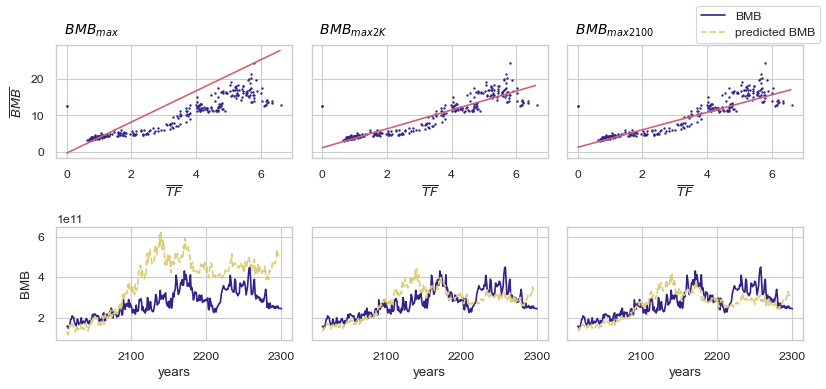

In [61]:
if os.path.exists(fpath):
    print( f"The path '{fpath}' already exists.")
else:
    os.makedirs(fpath)
    print( f"The path '{fpath}' did not exist, so it has been created.")
dic_all_err = {}

for key in dic_area_of_interest.keys():
    dic_key = {}

  
    lst = dic_area_of_interest[key]

    a4_width = 8.27  # inches
    a4_height = 11.69
    colors = ['#117733', '#332288', '#DDCC77', '#CC6677']
    fs = 8

    df = df_org[df_org['Experiment']== exp].reset_index(drop=True)
#     df =  df[df['Model'].isin(Models)].reset_index(drop = True)
    for j,exp in enumerate(expnames):
        dic_exp ={}
        f,ax = plt.subplots(len(Models)*2,3,figsize=(a4_width, a4_height/3),sharey = 'row')
        
        for p,method in enumerate(methods):
            df_ms_method=pds_m[p]
            df_ms_n_method=pds_n[p]
            


            df = df_org[df_org['Experiment']== exp].reset_index(drop=True)
            df =  df[df['Model'].isin(Models)].reset_index(drop = True)

            ms_exp =df_ms_method[df_ms_method['Experiment']== exp].reset_index(drop=True)
            ms_exp= ms_exp[ms_exp['Model'].isin(Models)].reset_index(drop = True)
            ms_n_exp =df_ms_n_method[df_ms_n_method['Experiment']== exp].reset_index(drop=True)
            ms_n_exp= ms_n_exp[ms_n_exp['Model'].isin(Models)].reset_index(drop = True)



            for i in range (df.shape[0]):

                iy =0
    #             iy=i%2
                pth_way = df.iloc[i].Path
                #get shelf area

                pth_bmb = f'{pth}/{df.iloc[i].Experiment}/{variable2}/computed_{variable2}_AIS_{df.iloc[i].Model}_{df.iloc[i].Experiment}.nc'


                d3 = xr.open_dataset(pth_bmb,decode_times=False )

                #get shelf area
                pth_area = f'{pth_helene}/{df.iloc[i].Experiment}/{variable}/computed_{variable}_AIS_{df.iloc[i].Model}_{df.iloc[i].Experiment}.nc'
                d2 = xr.open_dataset(pth_area,decode_times=False )
                #thermal foring 
                if df.iloc[i].Model in ['DOE_MALI_4km', 'DOE_MALI_8km_Ant95', 'DOE_MALI_8km_AntMean']:
                    nmname = renamer[df.iloc[i].Model]
                else:
                    nmname = df.iloc[i].Model



                pth_var3 = f'{pth3}/{df.iloc[i].Experiment}/{variable3}/computed_{variable3}_AIS_{nmname}_{df.iloc[i].Experiment}.nc'





                d4 = xr.open_dataset(pth_var3,decode_times=False )




                tmin = np.min([d2.time.size,d3.time.size,d4.time.size])
                #melting per area
                the_ys = np.zeros((len(lst),tmin))
                the_areas = np.zeros((len(lst),tmin))
                the_tfs = np.zeros((len(lst),tmin))



                for k,nm in enumerate(lst):
                    the_ys[k,:]= d3[f'{variable2}{nm}'].values[:tmin]*factor
                    the_areas[k,:]= d2[f'{variable}{nm}'].values[:tmin]
                    the_tfs[k,:]= d4[f'{variable3}{nm}'].values[:tmin]*the_areas[k,:]



                y = np.sum(the_ys ,axis =0)
                area = np.sum( the_areas,axis = 0)
                TF = np.sum( the_tfs,axis = 0)/area

                ms = ms_exp.iloc[i][key]
                ms_n = ms_n_exp.iloc[i][key]
    #             print(f'models same{df.iloc[i].Model} and {ms_exp.iloc[i].Model} and {ms_n_exp.iloc[i].Model}')
                ix =1 +i*2
                ax2 = ax[ix,p]            

                if p ==0:
                    ax2.plot(d3.time[:tmin],y ,color = colors[1],label = f'BMB')
                    ax2.plot(d3.time[:tmin][:-2],ms*TF[:-2]*area[:-2] +ms_n*area[:-2],color = colors[2],linestyle ='dashed',label = f'predicted BMB')
                else:


                    ax2.plot(d3.time[:tmin],y ,color = colors[1])
                    ax2.plot(d3.time[:tmin][:-2],ms*TF[:-2]*area[:-2] +ms_n*area[:-2],color = colors[2],linestyle ='dashed')



                err = (ms*TF*area +ms_n -y)**2
                msk = np.isnan(err) | (y == 0)
                rmse = (np.sum(err[~msk])/err[~msk].size)**0.5
                if len(err[~msk]) !=0:
                    prmse = (( (1/err[~msk].size)*np.sum(err[~msk]))/np.sum(y[~msk]**2))**0.5 *100 # %
                    dic_exp[df.iloc[i].Model] =prmse.copy()

                else:
                    prmse = np.nan
                    dic_exp[df.iloc[i].Model] =np.nan

                df_info_exp = df_info[df_info['Experiment']==exp]
                if df.iloc[i].Model in ['DOE_MALI_4km', 'DOE_MALI_8km_Ant95', 'DOE_MALI_8km_AntMean']:
                    nmname = renamer[df.iloc[i].Model]
                else:
                    nmname = df.iloc[i].Model

                df_info_exp_model = df_info_exp[df_info_exp['fileID']==nmname]
                meltparam =  df_info_exp_model['Melt parameterisation'].values[0]
                icefront =  df_info_exp_model['ice front'].values[0]
                ax2.set_xlabel('years')
                if p ==0:
                    ax2.set_ylabel('BMB')
                ################### scatter plot
                ix =0 +i*2
                ax2 = ax[ix,p]  
                y_avg = y/area
                ax2.scatter(TF,y_avg,s = 0.8,color =colors[1])
                TF_even = np.arange(np.nanmin(TF[:-1]),np.nanmax(TF[:-1]),0.1)
                ax2.plot(TF_even,TF_even*ms+ms_n,color = colors[3])
               

                ax2.text(0.02, 1.2,f' {method}',transform=ax2.transAxes,fontsize = 10, va='top',color = 'black')
                ax2.set_xlabel('$\overline{TF}$')
                if p ==0:
                    ax2.set_ylabel('$\overline{BMB}$')
                    
                

            dic_key[exp]=dic_exp.copy()


        dic_all_err[key] = dic_key.copy()

f.tight_layout()
f.legend()
f.savefig('figs/SI/Example_3methods_MS.jpeg')
f.savefig('figs/SI/Example_3methods_MS.pdf')

In [53]:
j

0

In [34]:
TF_even

array([0.87603742, 0.97603742, 1.07603742, 1.17603742, 1.27603742,
       1.37603742, 1.47603742, 1.57603742, 1.67603742, 1.77603742,
       1.87603742, 1.97603742, 2.07603742, 2.17603742, 2.27603742,
       2.37603742, 2.47603742, 2.57603742, 2.67603742, 2.77603742,
       2.87603742, 2.97603742, 3.07603742, 3.17603742, 3.27603742,
       3.37603742, 3.47603742, 3.57603742])

In [36]:
df_err = df_ms.copy()
df_err=df_err.drop(df_err.columns[3:21],axis=1)
df_err=df_err.drop(df_err.columns[4:7],axis=1)
for key in dic_area_of_interest.keys():
    df_err[key]=0

for i in range (df_err.shape[0]):
    model =df_err.iloc[i].Model
    exp =df_err.iloc[i].Experiment
    for j,key in enumerate(dic_area_of_interest.keys()):
        if np.isnan(dic_all_err[key][exp][model]):
            df_err.loc[i,key] = np.nan
        else:
            df_err.loc[i,key]= dic_all_err[key][exp][model].copy()
df_err.to_csv('tables/prmse_recalc_linear_meltsensetivity_from_BMB_max_TFuntil2K.csv')

In [37]:
print('done')

done
